# T003 · 分子筛选：不想要的子结构

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授特定领域技能，并为研究项目提供管道模板作为起点。

作者：

- Maximilian Driller, CADD seminar, 2017, Charité/FU Berlin
- Sandra Krüger, CADD seminar, 2018, Charité/FU Berlin

__教程 T003__：本教程是 [首篇 TeachOpenCADD 论文](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x) 中描述的 TeachOpenCADD 流程的一部分，包括 T001-T010 教程。

## 本教程目标

在我们的筛选库中，有些子结构是我们不希望包含的。在本教程中，我们将学习不同类型的不想要的子结构，以及如何使用 RDKit 来查找、突出显示和移除它们。

### 理论内容

* 不想要的子结构
* 泛分析干扰化合物（PAINS）

### 实践内容

* 加载和可视化数据
* 筛选 PAINS
* 筛选不想要的子结构
* 突出显示子结构
* 子结构统计

### 参考文献

* 泛分析干扰化合物（[wikipedia](https://en.wikipedia.org/wiki/Pan-assay_interference_compounds), [_J. Med. Chem._ (2010), **53**, 2719-2740](https://pubs.acs.org/doi/abs/10.1021/jm901137j)）
* Brenk *et al.* 定义的不想要的子结构（[_Chem. Med. Chem._ (2008), **3**, 435-44](https://onlinelibrary.wiley.com/doi/full/10.1002/cmdc.200700139)）
* 灵感来自 Teach-Discover-Treat 教程（[repository](https://github.com/sriniker/TDT-tutorial-2014/blob/master/TDT_challenge_tutorial.ipynb)）
* RDKit（[repository](https://github.com/rdkit/rdkit), [documentation](https://www.rdkit.org/docs/index.html)）

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 3
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## Theory

## 理论

### 不想要的子结构

子结构可能是不利的，例如，因为它们具有毒性或反应性，由于不利的药代动力学性质，或者因为它们可能干扰某些检测方法。如今，药物发现活动常常涉及[高通量筛选](https://en.wikipedia.org/wiki/High-throughput_screening)。过滤不想要的子结构可以帮助组建更高效的筛选库，从而节省时间和资源。

Brenk *等人*（[_Chem. Med. Chem._ (2008), **3**, 435-44](https://onlinelibrary.wiley.com/doi/full/10.1002/cmdc.200700139)）已经汇编了一个不利子结构的列表，用于筛选治疗被忽视疾病化合物的库。这些不想要特征示例包括硝基（致突变性）、硫酸盐和磷酸盐（可能导致不利的药代动力学性质）、2-卤代吡啶和硫醇（反应性）。该不想要子结构列表发表于上述论文中，并将用于本教程的实践部分。

### 泛分析干扰化合物（PAINS）

[PAINS](https://en.wikipedia.org/wiki/Pan-assay_interference_compounds) 是在高通量筛选（HTS）中经常出现的化合物，尽管它们实际上是假阳性。PAINS 在多个靶标上显示活性，而非针对特定靶标。这种行为是由非特异性结合或与检测成分的相互作用造成的。Baell 等人（[_J. Med. Chem._ (2010), **53**, 2719-2740](https://pubs.acs.org/doi/abs/10.1021/jm901137j)）的研究聚焦于干扰检测信号的子结构。他们描述了可帮助识别此类 PAINS 的子结构，并提供了一个可用于子结构过滤的列表。

![PAINS](images/PAINS_Figure.jpeg)

*图 1：* PAINS 背景下的特异性和非特异性结合。图取自 [Wikipedia](https://commons.wikimedia.org/wiki/File:PAINS_Figure.tif)。

### Load and visualize data

## 实践

In [2]:
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

/opt/miniconda3/envs/T003_3120/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.


In [3]:
# 定义路径
HERE = Path(_dh[-1])
DATA = HERE / "data"

In [4]:
# 从 Talktorial T2 加载数据
egfr_data = pd.read_csv(DATA / "EGFR_compounds_lipinski.csv", index_col=0)
# 删除不必要的信息
print("Dataframe shape:", egfr_data.shape)
egfr_data.drop(columns=["molecular_weight", "n_hbd", "n_hba", "logp"], inplace=True)
egfr_data.head()

Dataframe shape: (4635, 10)


,molecule_chembl_id,IC50,units,smiles,pIC50,ro5_fulfilled
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,True
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,True
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,True
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910,True
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,True


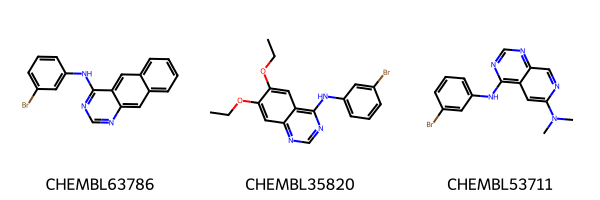

In [5]:
# 添加分子列
PandasTools.AddMoleculeColumnToFrame(egfr_data, smilesCol="smiles")
# 绘制前 3 个分子
Chem.Draw.MolsToGridImage(
    list(egfr_data.head(3).ROMol),
    legends=list(egfr_data.head(3).molecule_chembl_id),
)

### 加载和可视化数据

In [6]:
# 初始化过滤器
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog(params)

In [7]:
# 搜索 PAINS
matches = []
clean = []
for index, row in tqdm(egfr_data.iterrows(), total=egfr_data.shape[0]):
    molecule = Chem.MolFromSmiles(row.smiles)
    entry = catalog.GetFirstMatch(molecule)  # 获取第一个匹配的 PAINS
    if entry is not None:
        # 存储 PAINS 信息
        matches.append(
            {
                "chembl_id": row.molecule_chembl_id,
                "rdkit_molecule": molecule,
                "pains": entry.GetDescription().capitalize(),
            }
        )
    else:
        # 收集不含 PAINS 的分子的索引
        clean.append(index)

matches = pd.DataFrame(matches)
egfr_data = egfr_data.loc[clean]  # 保留不含 PAINS 的分子

100%|██████████| 4635/4635 [00:18<00:00, 246.19it/s]


In [8]:
# NBVAL_CHECK_OUTPUT
print(f"Number of compounds with PAINS: {len(matches)}")
print(f"Number of compounds without PAINS: {len(egfr_data)}")

Number of compounds with PAINS: 408
Number of compounds without PAINS: 4227


首先，我们导入所需的库，从**教程 T002**加载我们筛选过的数据集，并绘制出第一个分子。

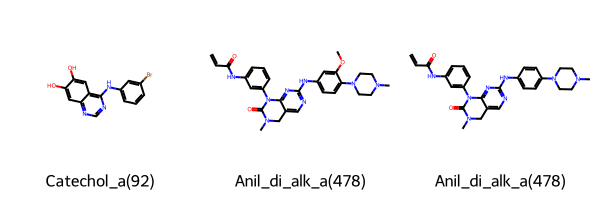

In [9]:
Chem.Draw.MolsToGridImage(
    list(matches.head(3).rdkit_molecule),
    legends=list(matches.head(3)["pains"]),
)

### Filter and highlight unwanted substructures

Some lists of unwanted substructures, like PAINS, are already implemented in RDKit. However, it is also possible to use an external list and get the substructure matches manually. 
Here, we use the list provided in the supporting information from Brenk *et al.* ([_Chem. Med. Chem._ (2008), **3**, 535-44](https://onlinelibrary.wiley.com/doi/full/10.1002/cmdc.200700139)).

In [10]:
substructures = pd.read_csv(DATA / "unwanted_substructures.csv", sep=r"\s+")
substructures["rdkit_molecule"] = substructures.smarts.apply(Chem.MolFromSmarts)
print("Number of unwanted substructures in collection:", len(substructures))
# NBVAL_CHECK_OUTPUT

Number of unwanted substructures in collection: 105


Let's have a look at a few substructures.

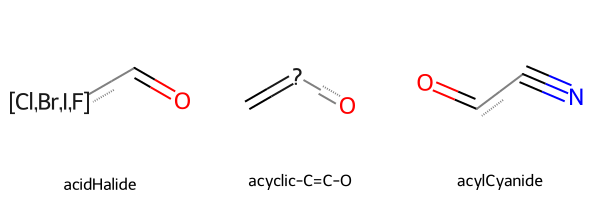

In [11]:
Chem.Draw.MolsToGridImage(
    mols=substructures.rdkit_molecule.tolist()[2:5],
    legends=substructures.name.tolist()[2:5],
)

Search our filtered dataframe for matches with these unwanted substructures.

In [12]:
# 搜索不想要的子结构
matches = []
clean = []
for index, row in tqdm(egfr_data.iterrows(), total=egfr_data.shape[0]):
    molecule = Chem.MolFromSmiles(row.smiles)
    match = False
    for _, substructure in substructures.iterrows():
        if molecule.HasSubstructMatch(substructure.rdkit_molecule):
            matches.append(
                {
                    "chembl_id": row.molecule_chembl_id,
                    "rdkit_molecule": molecule,
                    "substructure": substructure.rdkit_molecule,
                    "substructure_name": substructure["name"],
                }
            )
            match = True
    if not match:
        clean.append(index)

matches = pd.DataFrame(matches)
egfr_data = egfr_data.loc[clean]

100%|██████████| 4227/4227 [00:31<00:00, 134.35it/s]


In [13]:
# NBVAL_CHECK_OUTPUT
print(f"Number of found unwanted substructure: {len(matches)}")
print(f"Number of compounds without unwanted substructure: {len(egfr_data)}")

Number of found unwanted substructure: 3234
Number of compounds without unwanted substructure: 2088


### 筛选 PAINS

PAINS 过滤器已经在 RDKit 中实现（[文档](http://rdkit.org/docs/source/rdkit.Chem.rdfiltercatalog.html)）。这种预定义的过滤器可以通过 `FilterCatalog` 类应用。让我们学习如何使用它。

Let's have a look at the first 3 identified unwanted substructures. Since we have access to the underlying SMARTS patterns we can highlight the substructures within the RDKit molecules.

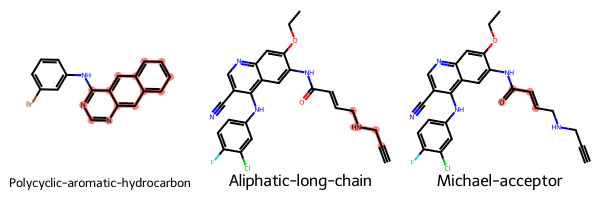

In [14]:
to_highlight = [
    row.rdkit_molecule.GetSubstructMatch(row.substructure) for _, row in matches.head(3).iterrows()
]
Chem.Draw.MolsToGridImage(
    list(matches.head(3).rdkit_molecule),
    highlightAtomLists=to_highlight,
    legends=list(matches.head(3).substructure_name),
)

### Substructure statistics

Finally, we want to find the most frequent substructure found in our data set. The Pandas `DataFrame` provides convenient methods to group containing data and to retrieve group sizes.

In [15]:
# NBVAL_CHECK_OUTPUT
groups = matches.groupby("substructure_name")
group_frequencies = groups.size()
group_frequencies.sort_values(ascending=False, inplace=True)
group_frequencies.head(10)

substructure_name
Michael-acceptor               1113
Aliphatic-long-chain            489
Oxygen-nitrogen-single-bond     367
triple-bond                     252
nitro-group                     177
imine                           150
Thiocarbonyl-group              114
aniline                          64
halogenated-ring                 62
conjugated-nitrile-group         59
dtype: int64

## Discussion
In this talktorial we learned two possibilities to perform a search for unwanted substructures with RDKit: 

* The `FilterCatalog` class can be used to search for predefined collections of substructures, e.g., PAINS.
* The `HasSubstructMatch()` function to perform manual substructure searches.

Actually, PAINS filtering could also be implemented via manual substructure searches with `HasSubstructMatch()`. Furthermore, the substructures defined by Brenk *et al.* ([_Chem. Med. Chem._ (2008), **3**, 535-44](https://onlinelibrary.wiley.com/doi/full/10.1002/cmdc.200700139)) are already implemented as a `FilterCatalog`. Additional pre-defined collections can be found in the RDKit [documentation](http://rdkit.org/docs/source/rdkit.Chem.rdfiltercatalog.html). 

So far, we have been using the `HasSubstructMatch()` function, which only yields one match per compound. With the `GetSubstructMatches()` function ([documentation](https://www.rdkit.org/docs/source/rdkit.Chem.rdchem.html)) we have the opportunity to identify all occurrences of a particular substructure in a compound.
In case of PAINS, we have only looked at the first match per molecule (`GetFirstMatch()`). If we simply want to filter out all PAINS this is enough. However, we could also use `GetMatches()` in order to see all critical substructures of a molecule.

Detected substructures can be handled in two different fashions: 

* Either, the substructure search is applied as a filter and the compounds are excluded from further testing to save time and money. 
* Or, they can be used as warnings, since ~5 % of FDA-approved drugs were found to contain PAINS ([_ACS. Chem. Biol._ (2018), **13**, 36-44](https://pubs.acs.org/doi/10.1021/acschembio.7b00903)). In this case experts can judge manually, if an identified substructure is critical or not.

## Quiz
* Why should we consider removing "PAINS" from a screening library? What is the issue with these compounds?
* Can you find situations when some unwanted substructures would not need to be removed?
* How are the substructures we used in this tutorial encoded?